# Assignment 1: Random Number Generation
**Simulations in Statistics (52001)**

---

This notebook contains the solutions to the three questions in Assignment 1:

1. **Q1:** Knuth's algorithm for pseudo-random number generation
2. **Q2:** Envelope rejection sampling for the Gamma distribution
3. **Q3:** Ratio-of-uniforms method for the Normal distribution

---

## Question 1: Knuth's Algorithm

### Theory

Knuth's algorithm is a **lagged Fibonacci generator** that produces pseudo-random numbers using the recursion:

$$X_n = (X_{n-j} + X_{n-k}) \bmod m$$

for integers $j, k, m$ with $j < k$. The recursion requires an initial seed sequence $X_{-k+1}, X_{-k+2}, \dots, X_0$ of length $k$.

### Initialization via LCG

The seed sequence is produced by a **Linear Congruential Generator** (LCG):

$$X_0 = \text{seed}, \qquad X_{-(i+1)} = (1103515245 \times X_{-i} + 12345) \bmod 2^{32}, \quad 0 \leq i \leq k-2$$

This fills positions $X_{-(k-1)}, \dots, X_{-1}, X_0$ with $k$ integers. Then, Knuth's recursion generates the output sequence $X_1, X_2, \dots, X_n$.

### R Implementation

In [1]:
a1q1 <- function(n, j, k, m, seed){
  init <- numeric(k)
  init[k] <- seed
  if (k > 1) {
    for (idx in seq_len(k - 1)) {
      init[k - idx] <- (1103515245 * init[k - idx + 1] + 12345) %% (2^32)
    }
  }
  full_seq <- c(init, numeric(n))
  for (idx in (k + 1):(k + n)) {
    full_seq[idx] <- (full_seq[idx - j] + full_seq[idx - k]) %% m
  }
  full_seq[(k + 1):(k + n)]
}

### Running Q1

In [2]:
n_q1   <- 10000
j_q1   <- 36
k_q1   <- 99
m_q1   <- 2^30
seed_q1 <- 2022

X_q1 <- a1q1(n_q1, j_q1, k_q1, m_q1, seed_q1)

cat("First 10 values:", X_q1[1:10], "\n")
cat("Length:", length(X_q1), "\n")

First 10 values: 763984640 73105472 1045667840 925348928 380944128 500782144 604132728 1009222208 967207424 598733312 
Length: 10000 


### Visualizations: Q1

**Histogram of $U_n = X_n / m$:** If the generator is good, the normalized values should look uniform on $[0,1]$.

**2D Lattice Plot:** Plotting consecutive pairs $(X_n/m,\; X_{n+1}/m)$ reveals hidden structure. A truly random sequence would fill the square uniformly, but PRNGs often show lattice patterns.

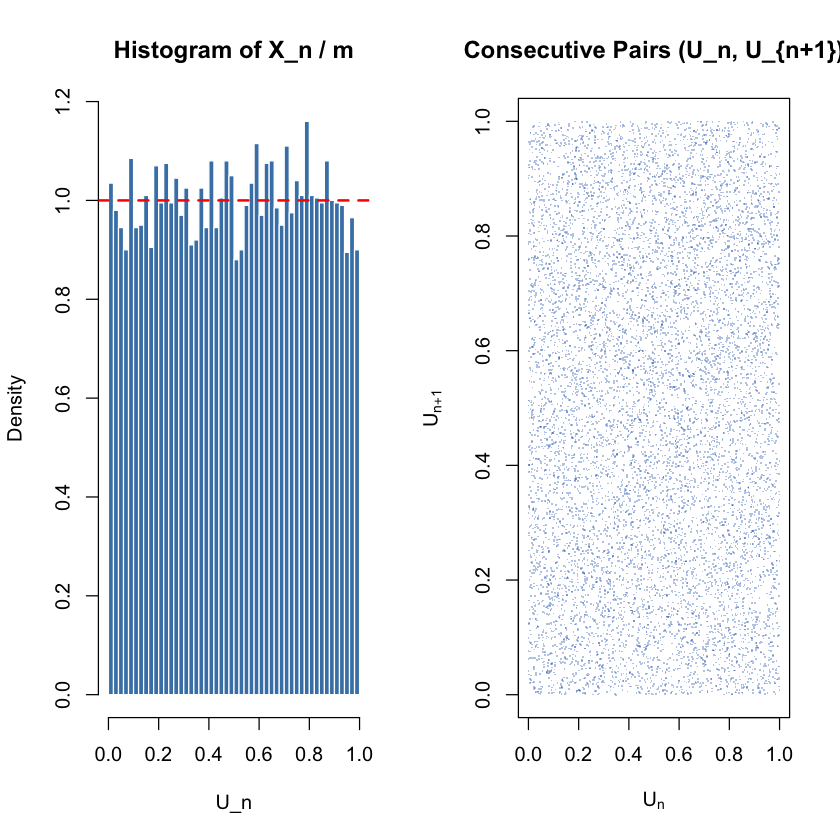

In [3]:
par(mfrow = c(1, 2))

U_q1 <- X_q1 / m_q1
hist(U_q1, breaks = 40, probability = TRUE,
     main = "Histogram of X_n / m",
     xlab = "U_n", col = "steelblue", border = "white")
abline(h = 1, col = "red", lwd = 2, lty = 2)

plot(U_q1[1:(n_q1 - 1)], U_q1[2:n_q1],
     pch = ".", cex = 0.5, col = rgb(0, 0.3, 0.7, 0.3),
     main = "Consecutive Pairs (U_n, U_{n+1})",
     xlab = expression(U[n]), ylab = expression(U[n+1]))

---

## Question 2: Envelope Rejection Sampling for the Gamma Distribution

### Theory

The **Gamma distribution** with unit rate and shape $r > 1$ (non-integer) has density:

$$f(x) = \frac{x^{r-1}\,e^{-x}}{\Gamma(r)}, \quad x > 0$$

We use envelope rejection sampling with a **proposal density** $g$. Let $m = \lfloor r \rfloor$ and $\lambda = m/r$:

$$g(x) = \frac{\lambda^m\,x^{m-1}\,e^{-\lambda x}}{\Gamma(m)}, \quad x > 0$$

This is the density of a $\text{Gamma}(m, \lambda)$ distribution, which equals the sum of $m$ independent $\text{Exp}(\lambda)$ random variables.

### Deriving the Acceptance Ratio

The ratio $f(x)/g(x)$ simplifies to:

$$\frac{f(x)}{g(x)} = \frac{\Gamma(m)}{\Gamma(r)}\,\lambda^{-m}\,x^{r-m}\,e^{-(1-\lambda)x}$$

This is maximized at $x^* = r$ (found by setting the derivative to zero), giving the **envelope constant**:

$$c = \frac{\Gamma(m)}{\Gamma(r)}\,\lambda^{-m}\,\left(\frac{r}{e}\right)^{r-m}$$

The acceptance ratio then becomes:

$$\frac{f(x)}{c \cdot g(x)} = \left(\frac{x}{r}\right)^{r-m} \exp\!\left((r-m)\left(1 - \frac{x}{r}\right)\right)$$

Note that $\log(t) + 1 - t \leq 0$ for all $t > 0$ (with equality at $t = 1$), so this ratio is always in $[0, 1]$.

**Algorithm:** Generate $X \sim g$ (sum of $m$ Exp($\lambda$) variates), draw $U \sim U(0,1)$, accept $X$ if $U \leq (X/r)^{r-m}\,e^{(r-m)(1-X/r)}$.

### R Implementation

In [4]:
a1q2 <- function(n, shape){
  r <- shape
  m_int <- floor(r)
  lam <- m_int / r
  delta <- r - m_int
  accepted_x <- numeric(0)
  accepted_u <- numeric(0)
  while (length(accepted_x) < n) {
    batch_size <- ceiling(1.5 * (n - length(accepted_x)))
    proposals <- rowSums(matrix(rexp(batch_size * m_int, rate = lam),
                                nrow = batch_size, ncol = m_int))
    u_vals <- runif(batch_size)
    ratio <- (proposals / r)^delta * exp(delta * (1 - proposals / r))
    is_acc <- u_vals <= ratio
    accepted_x <- c(accepted_x, proposals[is_acc])
    accepted_u <- c(accepted_u, u_vals[is_acc])
  }
  data.frame(X = accepted_x[1:n], U = accepted_u[1:n])
}

### Running Q2

In [5]:
n_q2     <- 10000
shape_q2 <- 4.7

out_q2 <- a1q2(n_q2, shape_q2)

cat("Shape r =", shape_q2, "\n")
cat("m = floor(r) =", floor(shape_q2), "\n")
cat("lambda = m/r =", floor(shape_q2) / shape_q2, "\n")
cat("Sample size:", nrow(out_q2), "\n")
cat("Sample mean:", mean(out_q2$X), " (theoretical:", shape_q2, ")\n")
cat("Sample sd:  ", sd(out_q2$X), " (theoretical:", sqrt(shape_q2), ")\n")

Shape r = 4.7 
m = floor(r) = 4 
lambda = m/r = 0.8510638 
Sample size: 10000 
Sample mean: 4.707157  (theoretical: 4.7 )
Sample sd:   2.169197  (theoretical: 2.167948 )


### Visualizations: Q2

**Histogram vs True Density:** The histogram of accepted samples should match $f(x) = x^{r-1}e^{-x}/\Gamma(r)$.

**Acceptance Ratio Function:** Shows how the ratio $(x/r)^{r-m}\,e^{(r-m)(1-x/r)}$ peaks at $x = r$ (where acceptance is most likely) and decays away from it.

**Proposal vs U Scatter:** Each proposal is plotted against its uniform $U$. Points below the acceptance curve (blue) are accepted; points above (red) are rejected.

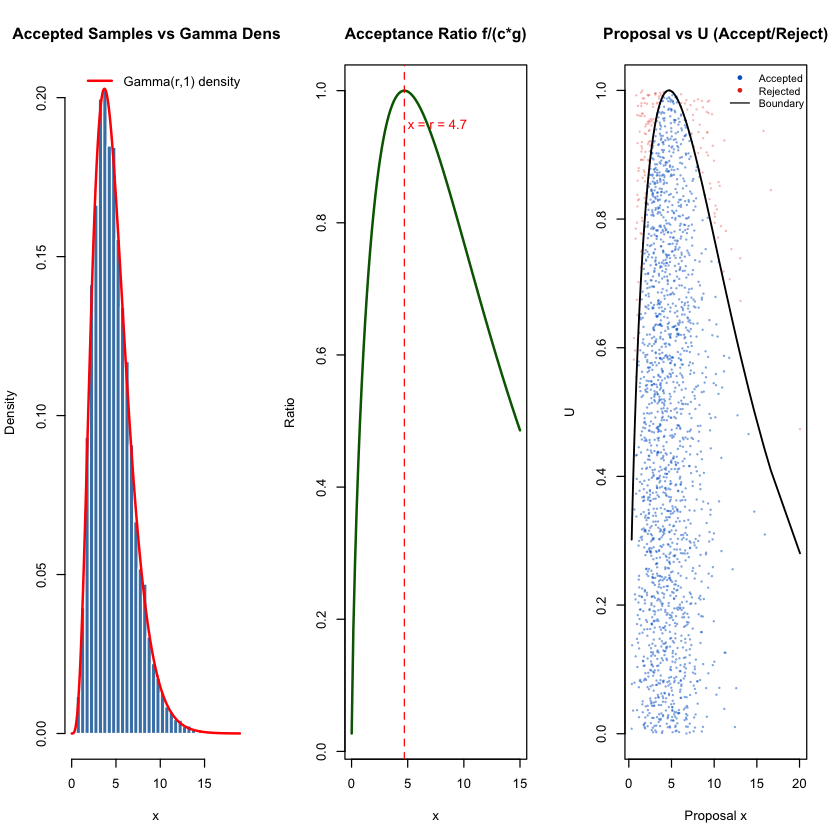

In [6]:
par(mfrow = c(1, 3))

r_val   <- shape_q2
m_val   <- floor(r_val)
delta   <- r_val - m_val

hist(out_q2$X, breaks = 60, probability = TRUE,
     main = "Accepted Samples vs Gamma Density",
     xlab = "x", col = "steelblue", border = "white")
x_curve <- seq(0.01, max(out_q2$X), length.out = 500)
lines(x_curve, dgamma(x_curve, shape = r_val, rate = 1),
      col = "red", lwd = 2)
legend("topright", legend = c("Gamma(r,1) density"),
       col = "red", lwd = 2, bty = "n")

acceptance_fn <- function(x) (x / r_val)^delta * exp(delta * (1 - x / r_val))
curve(acceptance_fn, from = 0.01, to = 15,
      main = "Acceptance Ratio f/(c*g)",
      xlab = "x", ylab = "Ratio", col = "darkgreen", lwd = 2)
abline(v = r_val, col = "red", lty = 2)
text(r_val + 0.3, 0.95, paste0("x = r = ", r_val), col = "red", adj = 0)

n_vis <- min(2000, nrow(out_q2))
all_proposals <- rowSums(matrix(rexp(n_vis * m_val, rate = m_val / r_val),
                                nrow = n_vis, ncol = m_val))
all_u <- runif(n_vis)
all_ratio <- acceptance_fn(all_proposals)
is_acc_vis <- all_u <= all_ratio

plot(all_proposals, all_u, pch = 16, cex = 0.4,
     col = ifelse(is_acc_vis, rgb(0, 0.4, 0.8, 0.5), rgb(0.9, 0.2, 0.1, 0.3)),
     main = "Proposal vs U (Accept/Reject)",
     xlab = "Proposal x", ylab = "U")
x_sort <- sort(all_proposals)
lines(x_sort, acceptance_fn(x_sort), col = "black", lwd = 1.5)
legend("topright", legend = c("Accepted", "Rejected", "Boundary"),
       col = c(rgb(0, 0.4, 0.8), rgb(0.9, 0.2, 0.1), "black"),
       pch = c(16, 16, NA), lty = c(NA, NA, 1), bty = "n", cex = 0.8)

---

## Question 3: Ratio-of-Uniforms for the Standard Normal

### Theory

The **ratio-of-uniforms** method generates samples from a distribution with kernel $h(x)$ by sampling uniformly from a 2D set and taking the ratio.

For the standard Normal distribution, the kernel is:

$$h(x) = e^{-x^2/2}, \quad -\infty < x < \infty$$

### Bounding Rectangle

The method requires:

$$m = \sup_x\, h(x) = 1$$

$$a = \inf_x\,\big(x\sqrt{h(x)}\big) = -\sqrt{2/e}, \qquad b = \sup_x\,\big(x\sqrt{h(x)}\big) = \sqrt{2/e}$$

(These are found by optimizing $x\,e^{-x^2/4}$, which peaks at $x = \pm\sqrt{2}$ with value $\sqrt{2/e}$.)

### The Algorithm

1. Sample $U_1 \sim U(0, 1)$ and $U_2 \sim U(-\sqrt{2/e},\; \sqrt{2/e})$ independently
2. **Accept** if $U_1^2 \leq \exp\!\Big(-\frac{1}{2}\,\frac{U_2^2}{U_1^2}\Big)$, i.e., the point $(U_1, U_2)$ lies inside the set $A$
3. The accepted sample is $X = U_2 / U_1 \sim N(0, 1)$

The set $A$ is defined as:

$$A = \Big\{(u_1, u_2) : 0 \leq u_1^2 \leq h(u_2/u_1)\Big\} = \Big\{(u_1, u_2) : u_1^2 \leq e^{-u_2^2/(2u_1^2)}\Big\}$$

### R Implementation

In [7]:
a1q3 <- function(n){
  bound <- sqrt(2 / exp(1))
  accepted_x <- numeric(0)
  accepted_u1 <- numeric(0)
  accepted_u2 <- numeric(0)
  while (length(accepted_x) < n) {
    batch_size <- ceiling(1.5 * (n - length(accepted_x)))
    u1 <- runif(batch_size, 0, 1)
    u2 <- runif(batch_size, -bound, bound)
    is_acc <- u1^2 <= exp(-0.5 * u2^2 / u1^2)
    accepted_x <- c(accepted_x, (u2 / u1)[is_acc])
    accepted_u1 <- c(accepted_u1, u1[is_acc])
    accepted_u2 <- c(accepted_u2, u2[is_acc])
  }
  data.frame(X = accepted_x[1:n], U1 = accepted_u1[1:n], U2 = accepted_u2[1:n])
}

### Running Q3

In [8]:
n_q3 <- 10000

out_q3 <- a1q3(n_q3)

cat("Sample size:", nrow(out_q3), "\n")
cat("Sample mean:", mean(out_q3$X), " (theoretical: 0)\n")
cat("Sample sd:  ", sd(out_q3$X), " (theoretical: 1)\n")
cat("X = U2/U1 check:", all(abs(out_q3$X - out_q3$U2 / out_q3$U1) < 1e-10), "\n")

Sample size: 10000 
Sample mean: 0.008209892  (theoretical: 0)
Sample sd:   1.001673  (theoretical: 1)
X = U2/U1 check: TRUE 


### Visualizations: Q3

**The Set $A$:** Plotting all $(U_1, U_2)$ proposals, coloring accepted (blue) vs rejected (red). The shape of $A$ is the region where acceptance occurs -- it has a distinctive curved boundary.

**Histogram vs Normal Density:** The histogram of $X = U_2/U_1$ should match the standard normal $\phi(x)$.

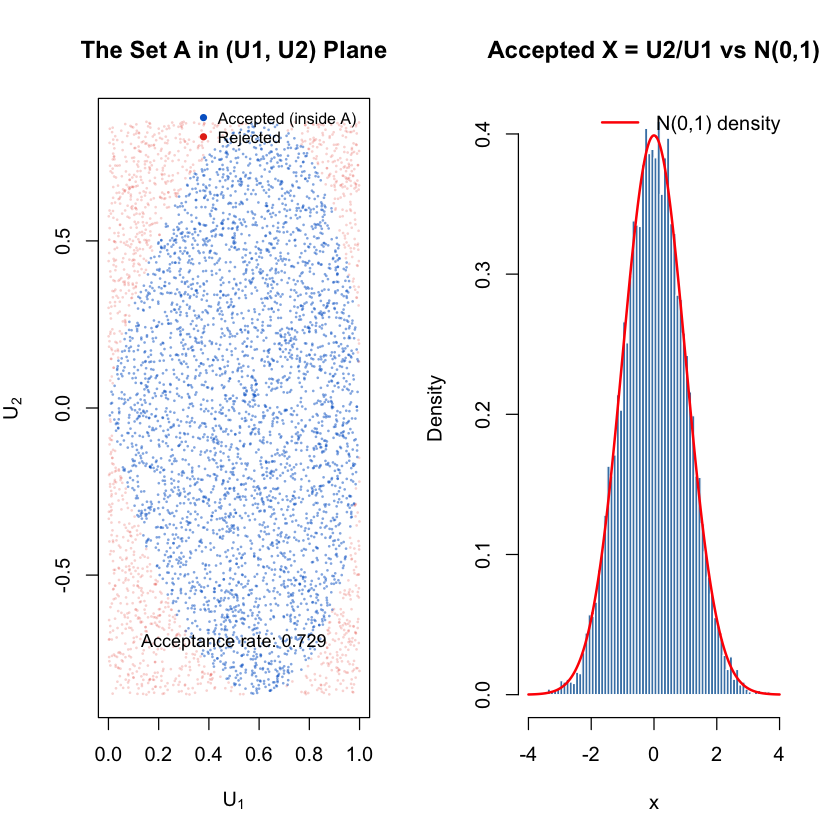

In [9]:
par(mfrow = c(1, 2))

bound_q3 <- sqrt(2 / exp(1))
n_vis_q3 <- 5000
u1_vis <- runif(n_vis_q3, 0, 1)
u2_vis <- runif(n_vis_q3, -bound_q3, bound_q3)
is_acc_q3 <- u1_vis^2 <= exp(-0.5 * u2_vis^2 / u1_vis^2)

plot(u1_vis, u2_vis, pch = 16, cex = 0.3,
     col = ifelse(is_acc_q3, rgb(0, 0.4, 0.8, 0.5), rgb(0.9, 0.2, 0.1, 0.2)),
     main = "The Set A in (U1, U2) Plane",
     xlab = expression(U[1]), ylab = expression(U[2]),
     xlim = c(0, 1), ylim = c(-bound_q3, bound_q3))
legend("topright", legend = c("Accepted (inside A)", "Rejected"),
       col = c(rgb(0, 0.4, 0.8), rgb(0.9, 0.2, 0.1)),
       pch = 16, bty = "n", cex = 0.8)
acc_rate <- sum(is_acc_q3) / n_vis_q3
text(0.5, -0.7, paste0("Acceptance rate: ", round(acc_rate, 3)), cex = 0.9)

hist(out_q3$X, breaks = 60, probability = TRUE,
     main = "Accepted X = U2/U1 vs N(0,1)",
     xlab = "x", col = "steelblue", border = "white",
     xlim = c(-4, 4))
x_norm <- seq(-4, 4, length.out = 500)
lines(x_norm, dnorm(x_norm), col = "red", lwd = 2)
legend("topright", legend = "N(0,1) density",
       col = "red", lwd = 2, bty = "n")